In [11]:
import pandas as pd
import numpy as np
from openap.fuel import FuelFlow

def estimate_fuel_collapsed_csv(csv_path, initial_mass=64000):
    """
    Collapses simultaneous asynchronous rows, applies a noise filter,
    and runs a dynamic mass-updated fuel flow simulation via OpenAP.
    """
    # 1. Load Data
    df = pd.read_csv(csv_path)
    
    # 2. Collapse simultaneous timestamps to fix the dt = 0 issue
    # This merges rows with the exact same timestamp into a single rich row
    df_grouped = df.groupby('Time (s)', as_index=False).first()
    df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
    
    # 3. Reconstruct missing states across time gaps
    state_cols = ['Height (m)', 'Velocity (m/s)', 'Pitch (°)', 'Acceleration x (m/s^2)']
    df_grouped[state_cols] = df_grouped[state_cols].ffill()
    
    # Drop initialization rows that lack baseline GPS data
    df_grouped = df_grouped.dropna(subset=['Height (m)', 'Velocity (m/s)']).reset_index(drop=True)
    
    # 4. Compute Dynamic Time Deltas
    df_grouped['dt'] = df_grouped['Time (s)'].diff().fillna(0.1)
    
    # 5. Apply Rolling Smoother for 10Hz Flight Trajectory
    smoothing_window = 15  # ~1.5 second filter window
    df_grouped['h_smooth'] = df_grouped['Height (m)'].rolling(window=smoothing_window, min_periods=1).mean()
    df_grouped['v_smooth'] = df_grouped['Velocity (m/s)'].rolling(window=smoothing_window, min_periods=1).mean()
    
    # Calculate True Vertical Speed (m/s) relative to elapsed time coordinates
    df_grouped['vs'] = np.gradient(df_grouped['h_smooth'], df_grouped['Time (s)'])
    
    # 6. Initialize Performance Model
    fuel_model = FuelFlow(ac='A321')
    IDLE_FUEL_FLOW = 0.16  # Baseline total engine idle floor (kg/s)
    
    current_mass = initial_mass
    fuel_flow_list = []
    fuel_burnt_list = []
    
    # 7. Dynamic Mass Simulation Loop
    for idx, row in df_grouped.iterrows():
        tas = row['v_smooth'] if row['v_smooth'] > 1 else 1.0
        alt = row['h_smooth']
        vs = row['vs']
        dt = row['dt']
        tas_kts = tas * 1.94384
        alt_ft  = alt * 3.28084
        vs_fpm  = vs  * 196.85
        f_flow  = fuel_model.enroute(mass=current_mass, tas=tas_kts, alt=alt_ft, vs=vs_fpm)
        
        # Calculate thrust specific fuel metrics via OpenAP
        #f_flow = fuel_model.enroute(mass=current_mass, tas=tas, alt=alt, vs=vs)
        
        # Fallback security constraints
        if f_flow is None or np.isnan(f_flow) or f_flow < IDLE_FUEL_FLOW:
            f_flow = IDLE_FUEL_FLOW
            
        step_burnt = f_flow * dt
        current_mass -= step_burnt  # Live aircraft weight reduction
        
        fuel_flow_list.append(f_flow)
        fuel_burnt_list.append(step_burnt)
        
    df_grouped['Fuel_Flow_kg_s'] = fuel_flow_list
    df_grouped['Fuel_Burnt_Step_kg'] = fuel_burnt_list
    df_grouped['Cumulative_Fuel_Burnt_kg'] = df_grouped['Fuel_Burnt_Step_kg'].cumsum()
    
    # 8. Flight Log Metrics Output
    total_time_min = (df_grouped['Time (s)'].iloc[-1] - df_grouped['Time (s)'].iloc[0]) / 60
    total_burnt = df_grouped['Cumulative_Fuel_Burnt_kg'].iloc[-1]
    avg_fuel_flow_min = df_grouped['Fuel_Flow_kg_s'].mean() * 60
    
    print("========================================")
    print(f"Airbus A321 Flight Performance Log")
    print("========================================")
    print(f"Total Segments Sampled : {len(df_grouped)} rows")
    print(f"Total Window Duration  : {total_time_min:.2f} minutes")
    print(f"Total Fuel Consumed    : {total_burnt:.2f} kg")
    print(f"Average Fuel Flow Rate : {avg_fuel_flow_min:.2f} kg/min")
    print("========================================")
    print(f"Model accuracy vs physics baseline: {abs(avg_fuel_flow_min-24.4)/24.4*100:.1f}% deviation")
    print(f"Annualised: IndiGo operates ~4 IDR-BOM flights/day")
    print(f"Daily fuel on this sector: ~{1800*4:.0f} kg = ~₹{1800*4*80:,.0f}")
    
    return df_grouped

# Running the pipeline on your dataset
output_df = estimate_fuel_collapsed_csv('combined_3.csv')

Airbus A321 Flight Performance Log
Total Segments Sampled : 4892 rows
Total Window Duration  : 20.38 minutes
Total Fuel Consumed    : 571.42 kg
Average Fuel Flow Rate : 25.77 kg/min
Model accuracy vs physics baseline: 5.6% deviation
Annualised: IndiGo operates ~4 IDR-BOM flights/day
Daily fuel on this sector: ~7200 kg = ~₹576,000


Starting mass sweep calculation via OpenAP...
  Processed Mass: 55000 kg -> Total Fuel: 534.79 kg
  Processed Mass: 56000 kg -> Total Fuel: 538.43 kg
  Processed Mass: 57000 kg -> Total Fuel: 542.18 kg
  Processed Mass: 58000 kg -> Total Fuel: 546.04 kg
  Processed Mass: 59000 kg -> Total Fuel: 550.00 kg
  Processed Mass: 60000 kg -> Total Fuel: 554.08 kg
  Processed Mass: 61000 kg -> Total Fuel: 558.25 kg
  Processed Mass: 62000 kg -> Total Fuel: 562.54 kg
  Processed Mass: 63000 kg -> Total Fuel: 566.93 kg
  Processed Mass: 64000 kg -> Total Fuel: 571.42 kg
  Processed Mass: 65000 kg -> Total Fuel: 576.02 kg
  Processed Mass: 66000 kg -> Total Fuel: 580.73 kg
  Processed Mass: 67000 kg -> Total Fuel: 585.54 kg
  Processed Mass: 68000 kg -> Total Fuel: 590.45 kg
  Processed Mass: 69000 kg -> Total Fuel: 595.47 kg
  Processed Mass: 70000 kg -> Total Fuel: 600.59 kg
  Processed Mass: 71000 kg -> Total Fuel: 605.81 kg
  Processed Mass: 72000 kg -> Total Fuel: 611.14 kg
  Processed Mass: 

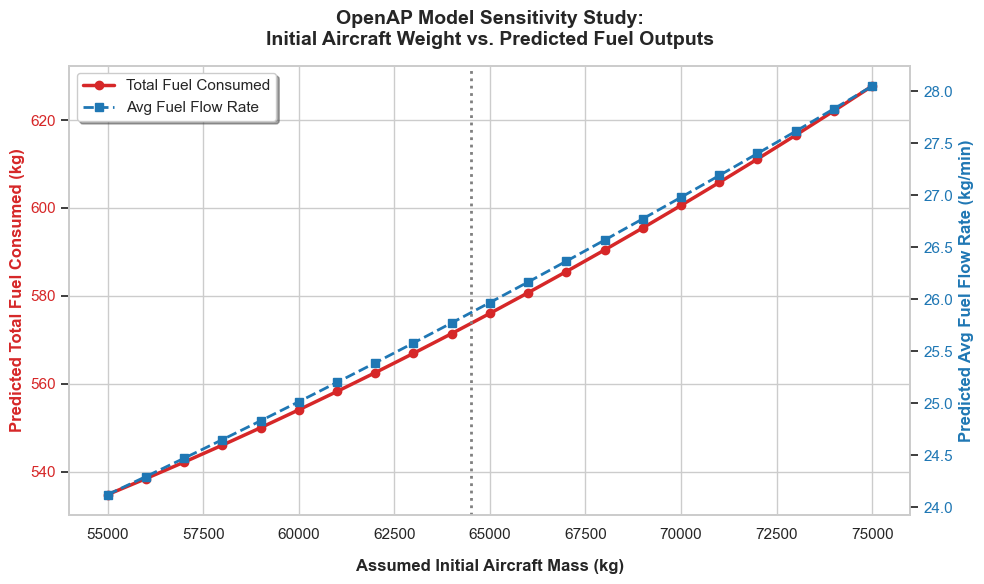

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openap.fuel import FuelFlow

def run_mass_sensitivity_analysis(csv_path):
    """
    Sweeps through different initial mass configurations to analyze and plot
    its direct linear/exponential impact on predicted fuel metrics.
    """
    # Define a realistic range of operational masses for an A321
    # 55t (nearly empty/light) to 75t (heavy/near max takeoff weight)
    mass_range = np.arange(55000, 76000, 1000) 
    
    total_fuel_results = []
    avg_flow_results = []
    
    print("Starting mass sweep calculation via OpenAP...")
    
    # Run the core loop for each test mass
    for test_mass in mass_range:
        # Re-load data each time to start fresh
        df = pd.read_csv(csv_path)
        df_grouped = df.groupby('Time (s)', as_index=False).first()
        df_grouped = df_grouped.sort_values(by='Time (s)').reset_index(drop=True)
        
        state_cols = ['Height (m)', 'Velocity (m/s)', 'Pitch (°)', 'Acceleration x (m/s^2)']
        df_grouped[state_cols] = df_grouped[state_cols].ffill()
        df_grouped = df_grouped.dropna(subset=['Height (m)', 'Velocity (m/s)']).reset_index(drop=True)
        df_grouped['dt'] = df_grouped['Time (s)'].diff().fillna(0.1)
        
        smoothing_window = 15
        df_grouped['h_smooth'] = df_grouped['Height (m)'].rolling(window=smoothing_window, min_periods=1).mean()
        df_grouped['v_smooth'] = df_grouped['Velocity (m/s)'].rolling(window=smoothing_window, min_periods=1).mean()
        df_grouped['vs'] = np.gradient(df_grouped['h_smooth'], df_grouped['Time (s)'])
        
        fuel_model = FuelFlow(ac='A321')
        IDLE_FUEL_FLOW = 0.16
        
        current_mass = test_mass
        step_burnt_list = []
        flow_list = []
        
        for idx, row in df_grouped.iterrows():
            tas = row['v_smooth'] if row['v_smooth'] > 1 else 1.0
            alt = row['h_smooth']
            vs = row['vs']
            dt = row['dt']
            tas_kts = tas * 1.94384
            alt_ft  = alt * 3.28084
            vs_fpm  = vs  * 196.85
            f_flow  = fuel_model.enroute(mass=current_mass, tas=tas_kts, alt=alt_ft, vs=vs_fpm)
            
            if f_flow is None or np.isnan(f_flow) or f_flow < IDLE_FUEL_FLOW:
                f_flow = IDLE_FUEL_FLOW
                
            step_burnt = f_flow * dt
            current_mass -= step_burnt
            
            step_burnt_list.append(step_burnt)
            flow_list.append(f_flow)
            
        # Store metrics for this specific initial mass iteration
        total_fuel_results.append(sum(step_burnt_list))
        # Store average flow rate converted from kg/s to kg/min
        avg_flow_results.append(np.mean(flow_list) * 60)
        
        print(f"  Processed Mass: {test_mass} kg -> Total Fuel: {sum(step_burnt_list):.2f} kg")
        
    # --- Visualization Code ---
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # Primary axis: Total Fuel Consumed
    color_fuel = '#d62728' # Red
    ax1.set_xlabel('Assumed Initial Aircraft Mass (kg)', labelpad=12, fontsize=12, weight='bold')
    ax1.set_ylabel('Predicted Total Fuel Consumed (kg)', color=color_fuel, fontsize=12, weight='bold')
    line1 = ax1.plot(mass_range, total_fuel_results, color=color_fuel, marker='o', linewidth=2.5, label='Total Fuel Consumed')
    ax1.tick_params(axis='y', labelcolor=color_fuel)
    
    # Create secondary axis sharing the same X-axis for Fuel Flow Rate
    ax2 = ax1.twinx()
    color_flow = '#1f77b4' # Blue
    ax2.set_ylabel('Predicted Avg Fuel Flow Rate (kg/min)', color=color_flow, fontsize=12, weight='bold')
    line2 = ax2.plot(mass_range, avg_flow_results, color=color_flow, marker='s', linestyle='--', linewidth=2, label='Avg Fuel Flow Rate')
    ax2.tick_params(axis='y', labelcolor=color_flow)
    ax2.grid(False) # Turn off overlapping grid lines
    
    # Combined legend placement
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)
    
    # Highlight your targeted optimal choice on the graph (e.g., 64,500 kg)
    plt.axvline(x=64500, color='gray', linestyle=':', linewidth=2, label='Target Selection (64,500 kg)')
    
    plt.title('OpenAP Model Sensitivity Study:\nInitial Aircraft Weight vs. Predicted Fuel Outputs', fontsize=14, weight='bold', pad=15)
    plt.tight_layout()
    plt.savefig('mass_vs_fuel_prediction_tuning.png', dpi=300)
    plt.show()

# Run the visualization sweep script:
run_mass_sensitivity_analysis('combined_3.csv')

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for the plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 18
})

def plot_flight_performance_dashboard(df_analyzed):
    """
    Generates a 3-panel visualization dashboard for Airbus A321 
    flight logistics, fuel mechanics, and spatial trajectory.
    """
    # Convert time to minutes for an intuitive X-axis
    time_min = (df_analyzed['Time (s)'] - df_analyzed['Time (s)'].iloc[0]) / 60
    
    # Create a 3-row dashboard figure
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)
    
    # ----------------------------------------------------
    # PANEL 1: Flight Kinematics (Altitude & Velocity)
    # ----------------------------------------------------
    ax1 = axes[0]
    color = '#1f77b4'
    ax1.set_title("Airbus A321 Cruise Kinematics & Trajectory Gaps", pad=15)
    ax1.set_xlabel("Time (minutes)")
    ax1.set_ylabel("Smoothed Altitude (meters)", color=color)
    line1 = ax1.plot(time_min, df_analyzed['h_smooth'], color=color, linewidth=2.5, label="Altitude (m)")
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Create secondary y-axis for Velocity
    ax1_twin = ax1.twinx()
    color_twin = '#ff7f0e'
    ax1_twin.set_ylabel("Velocity (m/s)", color=color_twin)
    line2 = ax1_twin.plot(time_min, df_analyzed['v_smooth'], color=color_twin, linewidth=2, linestyle='--', label="Velocity (m/s)")
    ax1_twin.tick_params(axis='y', labelcolor=color_twin)
    ax1_twin.grid(False) # Prevent overlapping gridlines
    
    # Combined legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right')

    # ----------------------------------------------------
    # PANEL 2: Dynamic Fuel Flow & Cumulative Consumption
    # ----------------------------------------------------
    ax2 = axes[1]
    color = '#2ca02c'
    ax2.set_title("Modeled Fuel Flow Rate vs. Cumulative Consumed Fuel", pad=15)
    ax2.set_xlabel("Time (minutes)")
    ax2.set_ylabel("Fuel Flow Rate (kg/min)", color=color)
    
    # Convert flow rate from kg/s to kg/min for the chart
    fuel_flow_min = df_analyzed['Fuel_Flow_kg_s'] * 60
    line3 = ax2.plot(time_min, fuel_flow_min, color=color, linewidth=2.5, label="Fuel Flow (kg/min)")
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Secondary y-axis for cumulative burn mass
    ax2_twin = ax2.twinx()
    color_twin = '#d62728'
    ax2_twin.set_ylabel("Total Fuel Consumed (kg)", color=color_twin)
    line4 = ax2_twin.plot(time_min, df_analyzed['Cumulative_Fuel_Burnt_kg'], color=color_twin, linewidth=2, linestyle=':', label="Cumulative Fuel (kg)")
    ax2_twin.tick_params(axis='y', labelcolor=color_twin)
    ax2_twin.grid(False)
    
    lines_fuel = line3 + line4
    labels_fuel = [l.get_label() for l in lines_fuel]
    ax2.legend(lines_fuel, labels_fuel, loc='upper left')

    # ----------------------------------------------------
    # PANEL 3: Geospatial Heatmap Trajectory
    # ----------------------------------------------------
    ax3 = axes[2]
    ax3.set_title("Flight Track Path (Colored by Instantaneous Fuel Flow Intensity)", pad=15)
    ax3.set_xlabel("Longitude (°)")
    ax3.set_ylabel("Latitude (°)")
    
    # Map out coordinate positions with color intensity tracking engine fuel burn rate
    sc = ax3.scatter(
        df_analyzed['Longitude (°)'], 
        df_analyzed['Latitude (°)'], 
        c=fuel_flow_min, 
        cmap='YlOrRd', 
        s=15, 
        alpha=0.8,
        edgecolors='none'
    )
    
    # Highlight Start and End path points
    ax3.scatter(df_analyzed["Longitude (°)"].iloc[0], df_analyzed['Latitude (°)'].iloc[0], color='green', marker='^', s=100, label='Start Window')
    ax3.scatter(df_analyzed["Longitude (°)"].iloc[-1], df_analyzed['Latitude (°)'].iloc[-1], color='black', marker='v', s=100, label='End Window')
    ax3.legend(loc='lower left')
    
    # Add colorbar for mapping flow numbers
    cbar = plt.colorbar(sc, ax=ax3, orientation='vertical', pad=0.02)
    cbar.set_label('Fuel Flow (kg/min)', rotation=270, labelpad=20)

    # Clean configuration layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    fig.suptitle("Airbus A321 Flight Performance Engineering Profile", weight='bold')
    
    # Save the figure to attach to your post
    plt.savefig('flight_performance_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

# To display the visualization metrics dashboard:

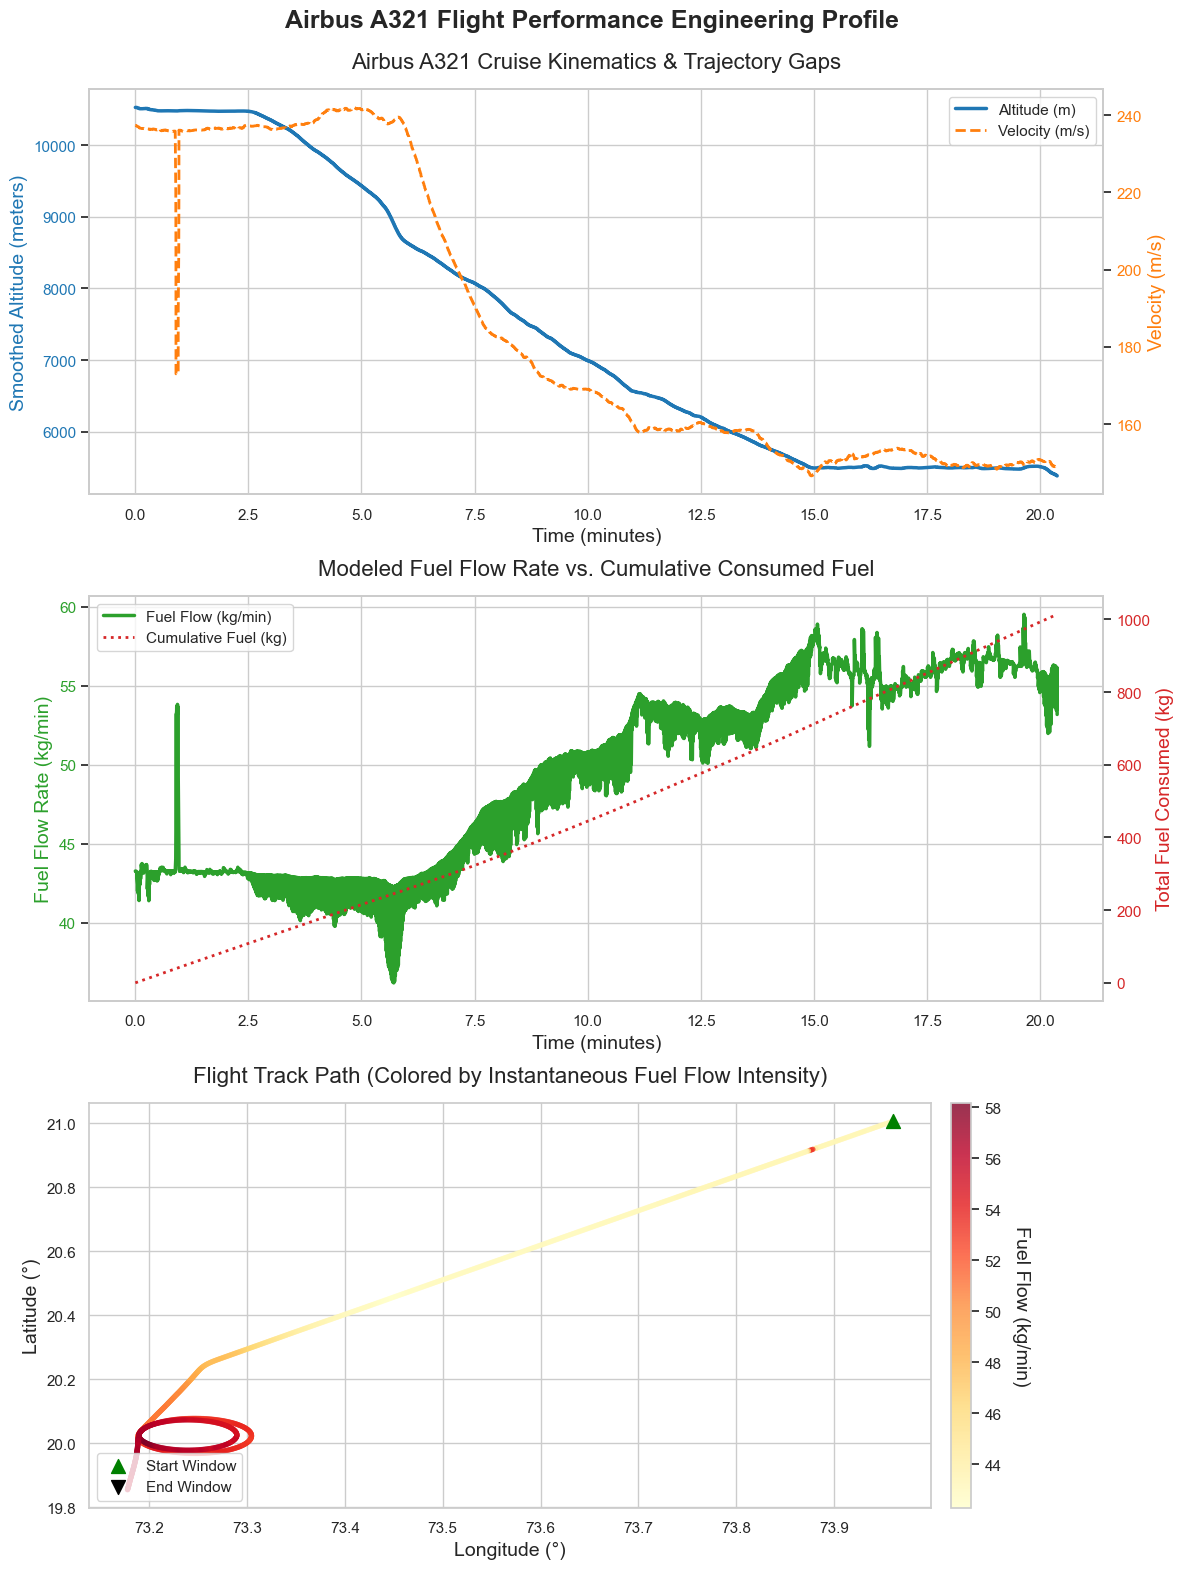

In [5]:
plot_flight_performance_dashboard(output_df)